# 基于简单移动平均线（SMA）的策略

基于简单移动平均线的交易策略已有数十年历史，源自技术分析领域。Brock 等人对此类策略进行了系统的实证研究，他们写道：

> "技术分析"一词是众多交易技术的总称……在本文中，我们探讨了两种最简单且最流行的技术规则：移动平均振荡器（moving average-oscillator）和交易区间突破（resistance and support levels）。在第一种方法中，买入和卖出信号由两条移动平均线生成，一条长周期，一条短周期……我们的研究表明，技术分析有助于预测股票变化。

本节先介绍 SMA 策略向量化回测的基础流程，然后将其封装为一个通用的 Python 类。

## 1. 基础知识

本小节聚焦于使用两条 SMA 的交易策略回测基础。示例使用 EUR/USD 汇率的日终（EOD）收盘数据。数据来源于 Refinitiv Eikon 数据 API，代表相应金融工具（RIC）的 EOD 值。

### 1.1 导入与读取数据

In [1]:
import numpy as np
import pandas as pd

In [2]:
raw = pd.read_csv('http://hilpisch.com/pyalgo_eikon_eod_data.csv',
                  index_col=0, parse_dates=True).dropna()

In [3]:
raw.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 2516 entries, 2010-01-04 to 2019-12-31
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AAPL.O  2516 non-null   float64
 1   MSFT.O  2516 non-null   float64
 2   INTC.O  2516 non-null   float64
 3   AMZN.O  2516 non-null   float64
 4   GS.N    2516 non-null   float64
 5   SPY     2516 non-null   float64
 6   .SPX    2516 non-null   float64
 7   .VIX    2516 non-null   float64
 8   EUR=    2516 non-null   float64
 9   XAU=    2516 non-null   float64
 10  GDX     2516 non-null   float64
 11  GLD     2516 non-null   float64
dtypes: float64(12)
memory usage: 255.5 KB


In [4]:
raw.head()

,AAPL.O,MSFT.O,INTC.O,AMZN.O,GS.N,SPY,.SPX,.VIX,EUR=,XAU=,GDX,GLD
Date,,,,,,,,,,,,
2010-01-04,30.572827,30.950,20.88,133.90,173.08,113.33,1132.99,20.04,1.4411,1120.00,47.71,109.80
2010-01-05,30.625684,30.960,20.87,134.69,176.14,113.63,1136.52,19.35,1.4368,1118.65,48.17,109.70
2010-01-06,30.138541,30.770,20.80,132.25,174.26,113.71,1137.14,19.16,1.4412,1138.50,49.34,111.51
2010-01-07,30.082827,30.452,20.60,130.00,177.67,114.19,1141.69,19.06,1.4318,1131.90,49.10,110.82
2010-01-08,30.282827,30.660,20.83,133.52,174.31,114.57,1144.98,18.13,1.4412,1136.10,49.84,111.37


### 1.2 提取 EUR/USD 数据

- 将 `EUR=` 列从原始数据中分离出来
- 转换为 `DataFrame` 对象
- 将列名重命名为 `price`

In [5]:
data = pd.DataFrame(raw['EUR='])

In [6]:
data.rename(columns={'EUR=': 'price'}, inplace=True)

In [7]:
data.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 2516 entries, 2010-01-04 to 2019-12-31
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   price   2516 non-null   float64
dtypes: float64(1)
memory usage: 39.3 KB


In [8]:
data.head()

,price
Date,
2010-01-04,1.4411
2010-01-05,1.4368
2010-01-06,1.4412
2010-01-07,1.4318
2010-01-08,1.4412


### 1.3 计算 SMA

使用 `rolling()` 方法配合延迟计算操作可以非常简洁地计算 SMA。

- 创建 **42 天** SMA 列（前 41 个值为 `NaN`）
- 创建 **252 天** SMA 列（前 251 个值为 `NaN`）

In [9]:
data['SMA1'] = data['price'].rolling(42).mean()

In [10]:
data['SMA2'] = data['price'].rolling(252).mean()

In [11]:
data.tail()

,price,SMA1,SMA2
Date,,,
2019-12-24,1.1087,1.107698,1.119630
2019-12-26,1.1096,1.107740,1.119529
2019-12-27,1.1175,1.107924,1.119428
2019-12-30,1.1197,1.108131,1.119333
2019-12-31,1.1210,1.108279,1.119231


### 1.4 可视化原始价格与 SMA

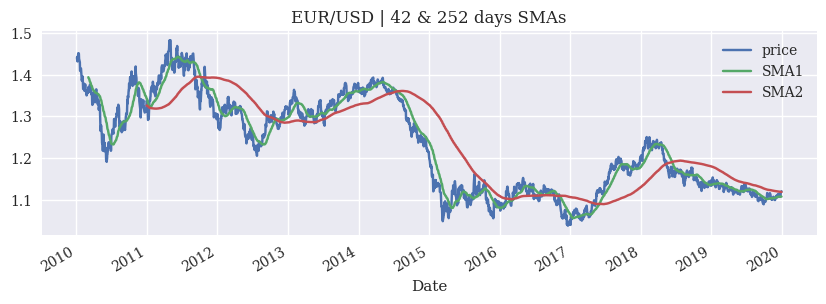

In [12]:
%matplotlib inline
from pylab import mpl, plt

plt.style.use('seaborn-v0_8')
mpl.rcParams['savefig.dpi'] = 300
mpl.rcParams['font.family'] = 'serif'
data.plot(title='EUR/USD | 42 & 252 days SMAs',
          figsize=(10, 3));
plt.show()

### 1.5 生成市场仓位信号

下一步是根据两条 SMA 之间的关系生成信号（也就是市场仓位）：

- 规则：当短期 SMA 高于长期 SMA 时做多，反之做空
- 用 `+1` 表示多头仓位，用 `-1` 表示空头仓位

得益于 `DataFrame` 的列直接比较能力，规则的实现只需一行代码：`np.where()` 在表达式为 `True` 的行返回 `+1`，在 `False` 的行返回 `-1`。

In [13]:
data['position'] = np.where(data['SMA1'] > data['SMA2'], 1, -1)

In [14]:
data.dropna(inplace=True)

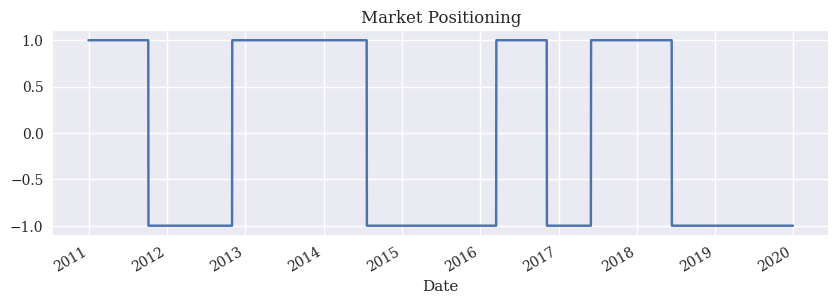

In [15]:
data['position'].plot(ylim=[-1.1, 1.1],
                      title='Market Positioning',
                      figsize=(10, 3));
plt.show()

### 1.6 计算对数收益率

In [16]:
data['benchmark_log_returns'] = np.log(data['price'] / data['price'].shift(1))

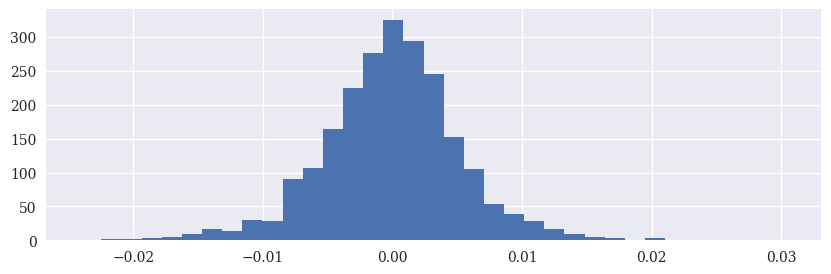

In [17]:
data['benchmark_log_returns'].hist(bins=35, figsize=(10, 3));
plt.show()

### 1.7 计算策略收益

要得到策略收益，需要将 `position` 列向后移动一个交易日（避免前视偏差），然后乘以 `returns` 列。

由于对数收益是可加的，对 `benchmark` 和 `strategy` 列求和可以初步比较策略相对于基础投资本身的表现。

In [18]:
data['strategy_log_returns'] = data['position'].shift(1) * data['benchmark_log_returns']

In [19]:
benchmark_total_log_return = data['benchmark_log_returns'].sum()
strategy_total_log_return = data['strategy_log_returns'].sum()
print(benchmark_total_log_return, strategy_total_log_return)

-0.1767305772293794 0.253120673154939


In [20]:
benchmark_final_wealth = np.exp(data['benchmark_log_returns'].sum())
strategy_final_wealth  = np.exp(data['strategy_log_returns'].sum())
print(benchmark_final_wealth, strategy_final_wealth)

0.838005531883084 1.2880386991503012


比较结果显示，策略相对于被动基准投资取得了胜利。

### 1.8 累积收益对比

通过 `cumsum` 计算时间上的累计求和，再应用指数函数 `np.exp()` 即可得到**累计收益 (equity)**，更全面地展示策略相对基础工具的表现。

In [21]:
data['benchmark_equity'] = data['benchmark_log_returns'].cumsum().apply(np.exp)
data['strategy_equity'] = data['strategy_log_returns'].cumsum().apply(np.exp)

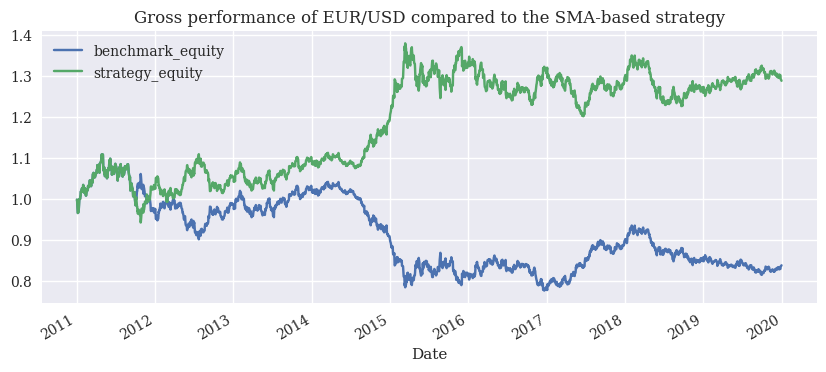

In [22]:
data[['benchmark_equity', 'strategy_equity']].plot(title='Gross performance of EUR/USD compared to the SMA-based strategy',                                               figsize=(10, 4));
plt.show()

### 1.9 风险-收益统计

计算股票和策略的**年化平均收益**与**年化波动率**：

In [23]:
# 年化平均对数收益
benchmark_annual_log_return, strategy_annual_log_return = data[['benchmark_log_returns', 'strategy_log_returns']].mean() * 252
print('benchmark_annual_log_return = %.4f' % benchmark_annual_log_return)
print('strategy_annual_log_return = %.4f'% strategy_annual_log_return)

benchmark_annual_log_return = -0.0197
strategy_annual_log_return = 0.0282


In [24]:
# 年化平均常规收益
benchmark_annual_return, strategy_annual_return = np.exp(data[['benchmark_log_returns', 'strategy_log_returns']].mean() * 252) - 1
print('benchmark_annual_return = %.4f' % benchmark_annual_return)
print('strategy_annual_return = %.4f' % strategy_annual_return)

benchmark_annual_return = -0.0195
strategy_annual_return = 0.0286


In [25]:
# 年化对数收益标准差
benchmark_annual_volatility, strategy_annual_volatility = data[['benchmark_log_returns', 'strategy_log_returns']].std() * 252 ** 0.5
print('benchmark_annual_volatility = %.4f' % benchmark_annual_volatility)
print('strategy_annual_volatility = %.4f' % strategy_annual_volatility)

benchmark_annual_volatility = 0.0854
strategy_annual_volatility = 0.0854


In [26]:
# 年化常规收益标准差
benchmark_annual_volatility_simple, strategy_annual_volatility_simple = \
(data[['benchmark_log_returns', 'strategy_log_returns']].apply(np.exp) - 1).std() * 252 ** 0.5
print('benchmark_annual_volatility_simple = %.4f' % benchmark_annual_volatility_simple)
print('strategy_annual_volatility_simple = %.4f' % strategy_annual_volatility_simple)

benchmark_annual_volatility_simple = 0.0854
strategy_annual_volatility_simple = 0.0854


---
从结果来看，该策略明显优于基准：

1. 收益：
- 标的年化收益约为 -1.96%，整体是亏损的
- 策略年化收益约为 +2.8%，实现了正收益

👉 说明策略相对于标的具有明显的超额收益（alpha）

2. 波动率：
- 标的和策略的年化波动率都在 ~8.5% 左右

👉 风险水平几乎一致，没有明显增加

3. 风险收益比：
- 在风险基本相同的情况下，策略从负收益提升为正收益

👉 Sharpe Ratio 会显著优于标的

总体结论：
- 该策略在“不增加风险”的前提下提升了收益，是一个有效策略
- 收益绝对值不高（~2.8%），属于低收益策略
---

### 1.10 最大回撤与最长回撤期

在交易策略表现分析中，另两个常见的风险统计量是**最大回撤（maximum drawdown）**和**最长回撤期（longest drawdown period）**。

- 辅助统计量是**累计最大毛收益（cumulative maximum gross performance）**, 通过对策略毛收益应用 `cummax()` 方法得到。
- **最大回撤**就是这两列差值的最大值（约 18 个百分点）

In [27]:
data['strategy_equity_peak'] = data['strategy_equity'].cummax()
data['strategy_drawdown'] = data['strategy_equity'] - data['strategy_equity_peak']

In [28]:
data['strategy_drawdown']

Date
2010-12-31         NaN
2011-01-03    0.000000
2011-01-04   -0.003738
2011-01-05   -0.014951
2011-01-06   -0.026164
                ...   
2019-12-24   -0.077022
2019-12-26   -0.078078
2019-12-27   -0.087278
2019-12-30   -0.089816
2019-12-31   -0.091312
Name: strategy_drawdown, Length: 2265, dtype: float64

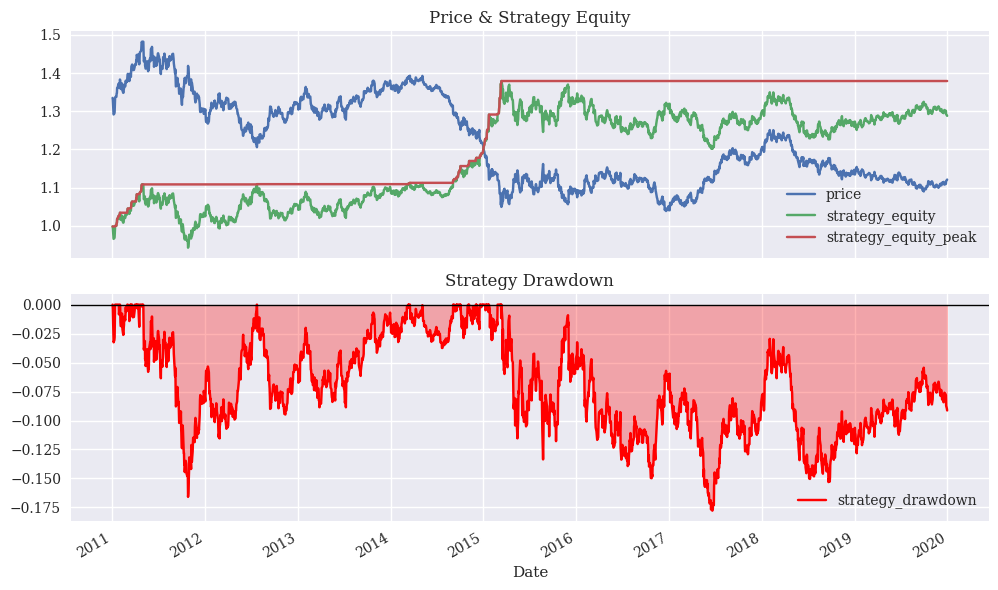

In [29]:
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

# 上图：价格 + 策略净值 + 峰值
data[['price', 'strategy_equity', 'strategy_equity_peak']].dropna().plot(ax=axes[0])
axes[0].set_title('Price & Strategy Equity')
axes[0].legend()

# 下图：回撤
data['strategy_drawdown'].plot(ax=axes[1], color='red')   # ← 关键：ax=axes[1]
axes[1].fill_between(data.index, data['strategy_drawdown'], 0, color='red', alpha=0.3)
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set_title('Strategy Drawdown')
axes[1].legend()

plt.tight_layout()
plt.show()

In [30]:
max_dd = data['strategy_drawdown'].min()
max_dd_date = data['strategy_drawdown'].idxmin()

print(f'Max Drawdown: {max_dd:.2%}  ({max_dd_date.date()})')

Max Drawdown: -17.78%  (2017-06-20)


- **最长回撤期**的确定稍复杂：

1. 找出毛收益等于其累计最大值的所有日期（即创新高的日期）
2. 计算所有这些日期之间的天数差
3. 选出最长的一段

这里最长回撤期长达 **596 天**——相当长的一段时间。

In [31]:
peaks = data.index[data['strategy_drawdown'] == 0]
gaps = peaks[1:] - peaks[:-1]
i = np.argmax(gaps)
dd_start = peaks[i]
dd_end   = peaks[i + 1]
longest_days = (dd_end - dd_start).days

print('longest_days=', longest_days)
print('dd_start=', dd_start)
print('dd_end=', dd_end)

longest_days= 596
dd_start= 2012-07-24 00:00:00
dd_end= 2014-03-12 00:00:00


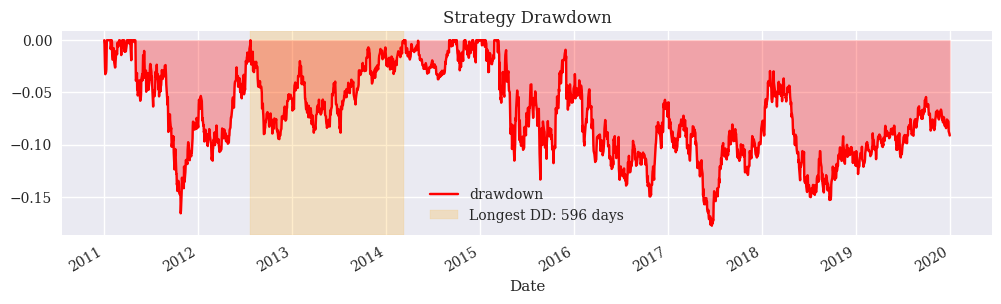

In [35]:
fig, ax = plt.subplots(figsize=(12, 3))


data['strategy_drawdown'].plot(ax=ax, color='red', label='drawdown')        # 先 plot
ax.fill_between(data.index, data['strategy_drawdown'], 0, color='red', alpha=0.3)  # 再 fill

ax.axvspan(dd_start, dd_end, color='orange', alpha=0.2,
           label=f'Longest DD: {longest_days} days')

ax.set_title('Strategy Drawdown')
ax.legend()
plt.show()

- **最长回撤期（含在途回撤）** 的确定在上述基础上再加一步，以覆盖"尚未恢复"的情况：


1. 找出毛收益等于其累计最大值的所有日期（即创新高的日期）
2. 将数据末尾也作为候选端点加入（应对最后一段还没回到新高的情形）
3. 计算所有这些日期之间的天数差
4. 选出最长的一段；若其终点正是数据末尾且仍在水下，则标记为 ongoing（尚未结束，实际可能更长）

这里最长回撤期长达 1754 天（ongoing）——策略自此之后再未回到历史高位。

In [36]:
endpoints = peaks.append(data.index[[-1]]).unique()

gaps = endpoints[1:] - endpoints[:-1]
i = np.argmax(gaps)
dd_start = endpoints[i]
dd_end   = endpoints[i + 1]
longest_days = (dd_end - dd_start).days

# 这段最长回撤是否仍在进行中
ongoing = (dd_end == data.index[-1]) and (data['strategy_drawdown'].iloc[-1] < 0)

print(f'longest_days = {longest_days}{"  (ongoing)" if ongoing else ""}')
print(f'dd_start = {dd_start.date()}')
print(f'dd_end   = {dd_end.date()}')

longest_days = 1754  (ongoing)
dd_start = 2015-03-13
dd_end   = 2019-12-31


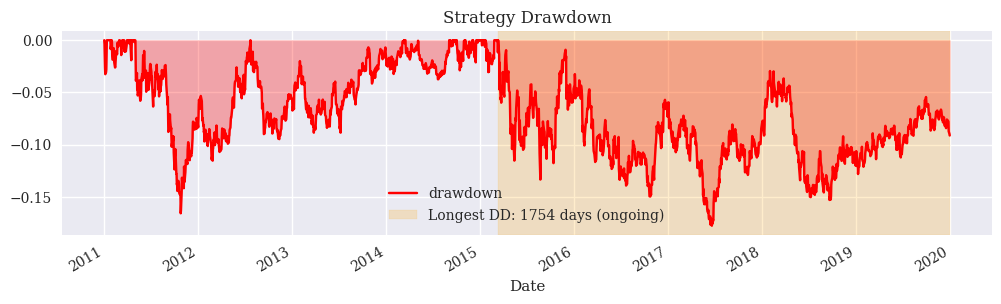

In [37]:
fig, ax = plt.subplots(figsize=(12, 3))

dd = data['strategy_drawdown']
dd.plot(ax=ax, color='red', label='drawdown')
ax.fill_between(data.index, dd, 0, color='red', alpha=0.3)

label = f'Longest DD: {longest_days} days' + (' (ongoing)' if ongoing else '')
ax.axvspan(dd_start, dd_end, color='orange', alpha=0.2, label=label)

ax.set_title('Strategy Drawdown')
ax.legend()
plt.show()

> **小结**：得益于 pandas 包及其核心 `DataFrame` 类的强大能力，向量化回测通常非常高效。许多关注的统计量——对数收益、累计收益、年化收益与波动率、最大回撤、最长回撤期——一般只需一行或几行代码即可计算。再加上简单的方法调用就能完成结果可视化，更是锦上添花。

## 2. 通用化方法

上一小节的交互式做法在小规模分析中很方便，但当需要构建一个更大型的回测程序，例如对 SMA 参数进行优化时，就需要一种更通用的方法。

下面将上面的流程封装为一个 `SMAVectorBacktester` 类，通过以下参数初始化实例：

- `symbol`：要使用的金融工具数据
- `SMA1`：短期 SMA 的时间窗口
- `SMA2`：长期 SMA 的时间窗口
- `start`：数据选取的起始日期
- `end`：数据选取的结束日期

类的完整代码见下一个代码块。

### 2.1 SMAVectorBacktester 类的实现

In [ ]:
%%writefile SMAVectorBacktester.py
#
# Python Module with Class
# for Vectorized Backtesting
# of SMA-based Strategies
#
import numpy as np
import pandas as pd
from scipy.optimize import brute


class SMAVectorBacktester(object):
    ''' Class for the vectorized backtesting of SMA-based trading strategies.

    Attributes
    ==========
    symbol: str
        RIC symbol (instrument) to work with
    SMA1: int
        time window in days for shorter SMA
    SMA2: int
        time window in days for longer SMA
    start: str
        start date for data retrieval
    end: str
        end date for data retrieval

    Methods
    =======
    get_data:
        retrieves and prepares the base data set
    set_parameters:
        sets new SMA parameters
    run_strategy:
        runs the backtest for the SMA-based strategy
    plot_results:
        plots the performance of the strategy compared to the symbol
    update_and_run:
        updates SMA parameters and returns the (negative) absolute performance
    optimize_parameters:
        implements a brute force optimization for the two SMA parameters
    '''

    def __init__(self, symbol, SMA1, SMA2, start, end):
        self.symbol = symbol
        self.SMA1 = SMA1
        self.SMA2 = SMA2
        self.start = start
        self.end = end
        self.results = None
        self.get_data()

    def get_data(self):
        ''' Retrieves and prepares the data. '''
        raw = pd.read_csv('http://hilpisch.com/pyalgo_eikon_eod_data.csv',
                          index_col=0, parse_dates=True).dropna()
        raw = pd.DataFrame(raw[self.symbol])
        raw = raw.loc[self.start:self.end]
        raw.rename(columns={self.symbol: 'price'}, inplace=True)
        raw['return'] = np.log(raw / raw.shift(1))
        raw['SMA1'] = raw['price'].rolling(self.SMA1).mean()
        raw['SMA2'] = raw['price'].rolling(self.SMA2).mean()
        self.data = raw

    def set_parameters(self, SMA1=None, SMA2=None):
        ''' Updates SMA parameters and resp. time series. '''
        if SMA1 is not None:
            self.SMA1 = SMA1
            self.data['SMA1'] = self.data['price'].rolling(
                self.SMA1).mean()
        if SMA2 is not None:
            self.SMA2 = SMA2
            self.data['SMA2'] = self.data['price'].rolling(
                self.SMA2).mean()

    def run_strategy(self):
        ''' Backtests the trading strategy. '''
        data = self.data.copy().dropna()
        data['position'] = np.where(data['SMA1'] > data['SMA2'], 1, -1)
        data['strategy'] = data['position'].shift(1) * data['return']
        data.dropna(inplace=True)
        data['creturns'] = data['return'].cumsum().apply(np.exp)
        data['cstrategy'] = data['strategy'].cumsum().apply(np.exp)
        self.results = data
        # 策略毛收益
        aperf = data['cstrategy'].iloc[-1]
        # 策略相对基准的超额/不足表现
        operf = aperf - data['creturns'].iloc[-1]
        return round(aperf, 2), round(operf, 2)

    def plot_results(self):
        ''' Plots the cumulative performance of the trading strategy
        compared to the symbol.
        '''
        if self.results is None:
            print('No results to plot yet. Run a strategy.')
        title = '%s | SMA1=%d, SMA2=%d' % (self.symbol,
                                           self.SMA1, self.SMA2)
        self.results[['creturns', 'cstrategy']].plot(title=title,
                                                     figsize=(10, 6))

    def update_and_run(self, SMA):
        ''' Updates SMA parameters and returns negative absolute performance
        (for minimization algorithm).

        Parameters
        ==========
        SMA: tuple
            SMA parameter tuple
        '''
        self.set_parameters(int(SMA[0]), int(SMA[1]))
        return -self.run_strategy()[0]

    def optimize_parameters(self, SMA1_range, SMA2_range):
        ''' Finds global maximum given the SMA parameter ranges.

        Parameters
        ==========
        SMA1_range, SMA2_range: tuple
            tuples of the form (start, end, step size)
        '''
        opt = brute(self.update_and_run, (SMA1_range, SMA2_range),
                    finish=None)
        return opt, -self.update_and_run(opt)


if __name__ == '__main__':
    smabt = SMAVectorBacktester('EUR=', 42, 252,
                                '2010-1-1', '2019-12-31')
    print(smabt.run_strategy())
    smabt.set_parameters(SMA1=20, SMA2=100)
    print(smabt.run_strategy())
    print(smabt.optimize_parameters((30, 50, 2), (200, 300, 2)))

### 2.2 使用 SMAVectorBacktester 类

下面通过一段交互式会话演示该类的使用方式：

1. 复现前一小节基于 EUR/USD 数据的回测
2. 通过暴力搜索优化 SMA 参数以获得最大毛收益
3. 基于最优参数绘制策略表现与基准的对比图

In [ ]:
import SMAVectorBacktester as SMA

In [ ]:
smabt = SMA.SMAVectorBacktester('EUR=', 42, 252,
                                '2010-1-1', '2019-12-31')

In [ ]:
# 使用初始参数回测，返回 (策略毛收益, 相对基准的超额收益)
smabt.run_strategy()

### 2.3 参数优化

`optimize_parameters()` 方法接受参数范围（起、止、步长），通过**暴力搜索**确定最优组合。

In [ ]:
%%time
smabt.optimize_parameters((30, 50, 2),
                          (200, 300, 2))

预期输出：

```
(array([ 48., 238.]), 1.5)
```

即最优参数组合为 **`SMA1 = 48`，`SMA2 = 238`**，对应的绝对收益为 **1.5（150%）**。

### 2.4 绘制最优策略表现

`plot_results()` 方法基于当前存储的参数值（此处即优化结果）绘制策略表现与基准对比图。

In [ ]:
smabt.plot_results()

## 总结

本节展示了使用两条 SMA 进行交易策略回测的完整流程：

1. **数据准备**：读取 EOD 数据并提取所需金融工具
2. **指标计算**：用 `rolling().mean()` 一行代码完成 SMA 计算
3. **信号生成**：用 `np.where()` 实现向量化的仓位规则
4. **绩效评估**：对数收益、累计收益、年化统计、最大回撤、最长回撤期
5. **代码封装**：将流程抽象为 `SMAVectorBacktester` 类，便于参数优化与复用

原始参数（42, 252）下策略毛收益约 **1.29**，优化后（48, 238）提升至 **1.5**——这也提示了我们后续要警惕**数据窥探与过拟合**的风险。